In [20]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

from plotting.utils_plots_matplotlib import hist_with_errors

In [21]:
score_files_paths = [
    "/home/tmlinare/Lund_tagging/lundtoptagger_data_rcif/scores/v2.1.5_GN2X_0.25percent_hypatia_run_31-32/*.root"
]
tree_name = "FlatSubstructureJetTree"

In [22]:
dsid_weight_map = {
    364703: 12823.94988,
    364704: 5081.45927,
    364705: 3017.75098,
    364706: 4371.00012,
    364707: 2349.98631,
    426345: 950.41935,
    801471: 0.0189,
    801859: 12.45803
}

In [23]:
score_files_paths_with_trees = [f"{path}:{tree_name}" for path in score_files_paths]

data = uproot.concatenate(score_files_paths_with_trees)

In [24]:
# This give the same output as just entering the variable name in a notebook cell
from IPython.display import display
display(data)

<Array [{fjet_m: 85.1, fjet_pt: 330, ...}, ...] type='848050 * {fjet_m: flo...'>

In [25]:
print("Signal jets:", np.sum(data["labels"]==1))
print("Background jets:", np.sum(data["labels"]==0))
print("Total:", len(data))

Signal jets: 47139
Background jets: 800911
Total: 848050


In [26]:
# weights = data["fjet_weight_pt"]
# weights = np.ones_like(data["fjet_weight_pt"])
weights = np.array([dsid_weight_map[dsid] for dsid in data["EventInfo_mcChannelNumber"]]) * data["EventInfo_mcEventWeight"]

In [27]:
models = {
    "LundNet": {
        "scores": data["fjet_LundNet_score"]
    },
    "LundNet+GN2X": {
        "scores": data["fjet_LundNet_plus_GN2X_score"]
    }
}

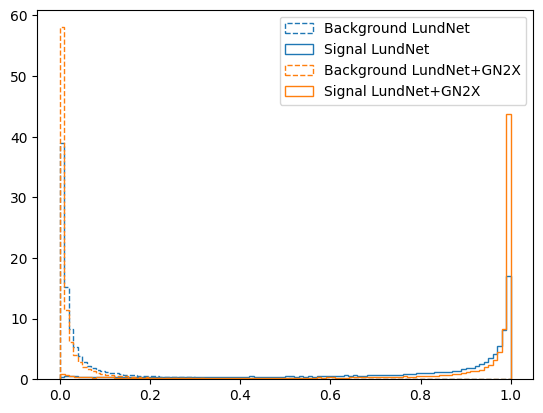

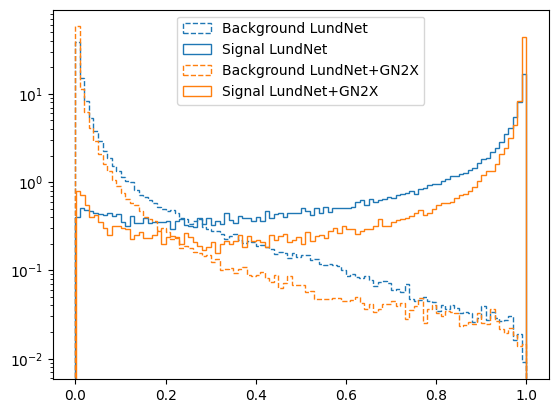

In [28]:
# Extract scores and labels
scores = data["fjet_LundNet_score"]
labels = data["labels"]

hist_params = dict(
    bins = 100,
    # range = (0, 1),
    density = True,
    # alpha = 0.5,
    histtype = "step"
)

for i, model in enumerate(models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
    plt.legend()
plt.show()

for i, model in enumerate(models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
    plt.legend()
    plt.yscale('log')
plt.show()

In [29]:
# TODO: working point should be calculated differently if weihts are used - sum of weights of signal jets with score above threshold should be 50% of total weight of signal jets
for model in models:
    # Sort scores corresponding to signal jets
    scores = models[model]["scores"]
    signal_scores = scores[labels == 1]
    sorted_signal_scores = np.sort(signal_scores)

    # Determine the threshold for 50% signal efficiency
    signal_efficiency = 0.5
    threshold_index = int(signal_efficiency * len(sorted_signal_scores))
    threshold_score = sorted_signal_scores[threshold_index]

    models[model]["threshold_score"] = threshold_score
    print(f"50% signal efficiency threshold for {model}:", threshold_score)

50% signal efficiency threshold for LundNet: 0.8957899808883667
50% signal efficiency threshold for LundNet+GN2X: 0.983116090297699


In [30]:
var_params = {
    "fjet_m":  {"title": "LRJ mass [GeV]",  "bins": 30, "range": (0, 500) },
    "fjet_pt": {"title": "LRJ $p_T$ [GeV]", "bins": 30, "range": (0, 3000)},
}

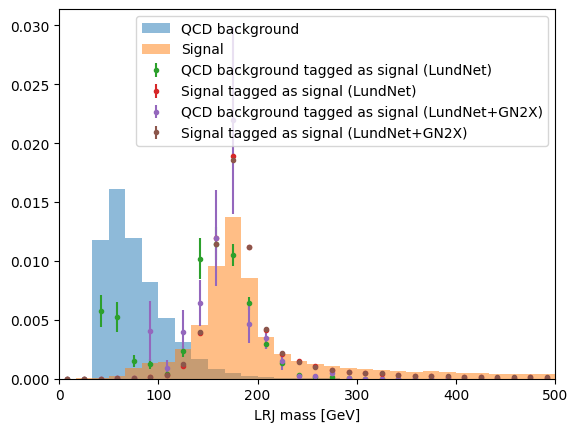

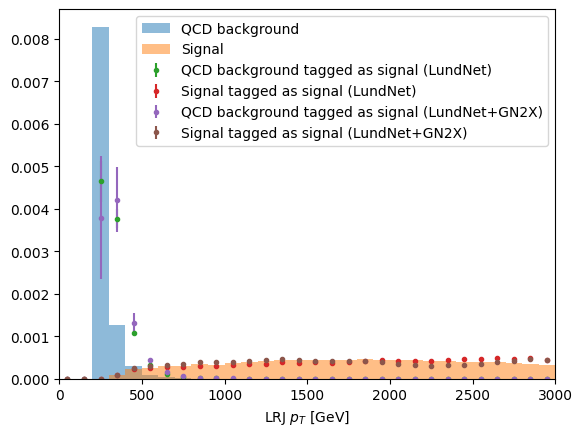

In [31]:
for var in var_params:
    var_data = data[var]
    tagged_as_signal = models[model]["scores"] > models[model]["threshold_score"]

    hist_params = dict(
        bins = var_params[var]["bins"],
        range = var_params[var]["range"],
        density = True,
        # histtype = "step"
    )
    errorbar_params = dict(
        fmt='.',
    )
    plt.hist(var_data[labels==0], weights=weights[labels==0], label="QCD background", **hist_params, alpha=0.5)
    plt.hist(var_data[labels==1], weights=weights[labels==1], label="Signal",         **hist_params, alpha=0.5)

    for model in models:
        tagged_as_signal = models[model]["scores"] > models[model]["threshold_score"]
        hist_with_errors(var_data[(labels==0) & tagged_as_signal], weights=weights[(labels==0) & tagged_as_signal], label=f"QCD background tagged as signal ({model})", **hist_params, **errorbar_params)
        hist_with_errors(var_data[(labels==1) & tagged_as_signal], weights=weights[(labels==1) & tagged_as_signal], label=f"Signal tagged as signal ({model})",         **hist_params, **errorbar_params)

    plt.xlim(var_params[var]["range"])
    plt.xlabel(var_params[var]["title"])
    plt.legend()
    plt.show()

In [32]:
from sklearn.metrics import roc_curve, auc

In [33]:
mass = data["fjet_m"]
mass_cut = (mass > 170) & (mass < 180)

y_truth_mass_cut = data["labels"][mass_cut]
weights_mass_cut = weights[mass_cut]

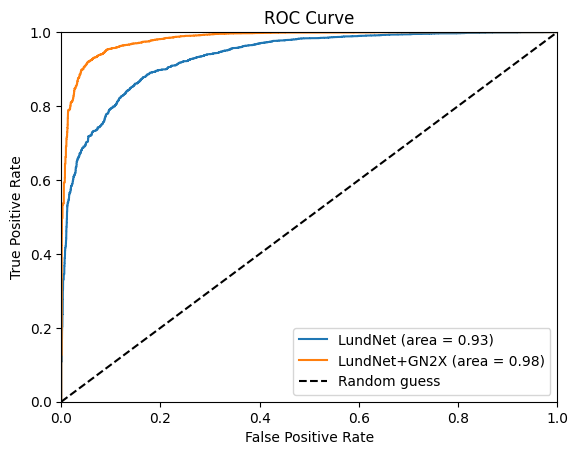

In [34]:
for trained_model in models:
    y_pred = models[trained_model]["scores"] if mass_cut is None else models[trained_model]["scores"][mass_cut]
    fpr, tpr, thresholds = roc_curve(y_truth_mass_cut, y_pred, sample_weight=weights_mass_cut)
    roc_auc = auc(fpr, tpr)

    models[trained_model]["fpr"] = fpr
    models[trained_model]["tpr"] = tpr

    plt.plot(fpr, tpr, label=f"{trained_model} (area = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "--", label="Random guess", color="black")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend(loc="lower right")
plt.show()

/tmp/ipykernel_125592/173204068.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.plot(tpr, 1/fpr, label=f"{trained_model}")


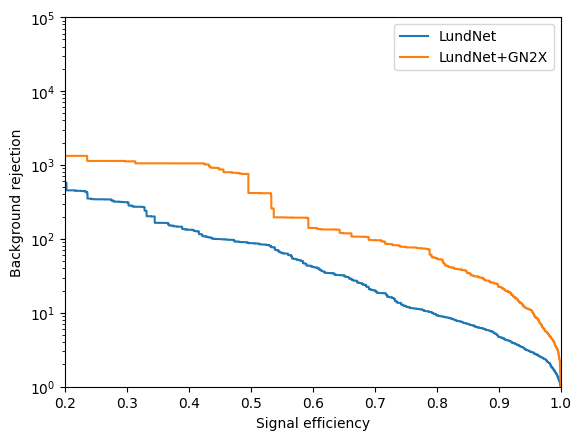

In [35]:
for trained_model in models:
    fpr = models[trained_model]["fpr"]
    tpr = models[trained_model]["tpr"]
    plt.plot(tpr, 1/fpr, label=f"{trained_model}")

plt.xlabel("Signal efficiency")
plt.ylabel("Background rejection")
plt.xlim([0.2, 1])
plt.ylim([1, 1e5])
plt.yscale("log")
plt.legend()
plt.show()